<a href="https://colab.research.google.com/github/krytoihacker228-create/-/blob/main/%D0%9A%D1%80%D0%B5%D0%B4%D0%B8%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
import random

path = kagglehub.dataset_download("laotse/credit-risk-dataset")
credit_df = pd.read_csv('credit_risk_dataset.csv')

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.


In [4]:
credit_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000.0,16.02,1.0,0.59,Y,3.0
1,21,9600,OWN,5.0,EDUCATION,B,1000.0,11.14,0.0,0.10,N,2.0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500.0,12.87,1.0,0.57,N,3.0
3,23,65500,RENT,4.0,MEDICAL,C,35000.0,15.23,1.0,0.53,N,2.0
4,24,54400,RENT,8.0,MEDICAL,C,35000.0,14.27,1.0,0.55,Y,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19078,28,33600,RENT,9.0,EDUCATION,C,14000.0,NaN,1.0,0.42,Y,5.0
19079,27,35000,RENT,0.0,PERSONAL,C,14000.0,14.27,1.0,0.40,Y,8.0
19080,28,29000,RENT,8.0,HOMEIMPROVEMENT,B,14000.0,11.99,1.0,0.48,N,9.0
19081,34,36000,RENT,5.0,DEBTCONSOLIDATION,A,14000.0,7.51,1.0,0.39,N,6.0


In [5]:
#Заполняю NaN
print(credit_df.isnull().sum())
credit_df_clean = credit_df.copy()
credit_df_clean['loan_int_rate'] = credit_df_clean['loan_int_rate'].fillna(credit_df_clean['loan_int_rate'].mean())
credit_df_clean['person_emp_length'] = credit_df_clean['person_emp_length'].fillna(credit_df_clean['person_emp_length'].bfill())
print(credit_df_clean.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              561
loan_intent                      0
loan_grade                       1
loan_amnt                        1
loan_int_rate                 1795
loan_status                      1
loan_percent_income              1
cb_person_default_on_file        1
cb_person_cred_hist_length       1
dtype: int64
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    1
loan_amnt                     1
loan_int_rate                 0
loan_status                   1
loan_percent_income           1
cb_person_default_on_file     1
cb_person_cred_hist_length    1
dtype: int64


In [6]:
#Заменяю категориалные признаки числовыми
print(credit_df['loan_intent'].unique())
print(credit_df['cb_person_default_on_file'].unique())
print(credit_df['person_home_ownership'].unique())
print(credit_df['loan_grade'].unique())

credit_df_clean['loan_intent'] = credit_df_clean['loan_intent'].map({'PERSONAL': 1, 'EDUCATION': 2,
                                                                     'MEDICAL': 3, 'VENTURE': 4,
                                                                     'HOMEIMPROVEMENT': 5, 'DEBTCONSOLIDATION': 6})
credit_df_clean['cb_person_default_on_file'] = credit_df_clean['cb_person_default_on_file'].map({'Y': 1, 'N': 0})
credit_df_clean['person_home_ownership'] = credit_df_clean['person_home_ownership'].map({'RENT': 1, 'OWN': 2, 'MORTGAGE': 3, 'OTHER': 4})
credit_df_clean['loan_grade'] = credit_df_clean['loan_grade'].map({'D':1, 'B':2, 'C':3, 'A':4, 'E':5, 'F':5, 'G':6})

print(credit_df_clean['loan_intent'].unique())
print(credit_df_clean['cb_person_default_on_file'].unique())
print(credit_df_clean['person_home_ownership'].unique())
print(credit_df_clean['loan_grade'].unique())
credit_df_clean

['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION' 'DE']
['Y' 'N' nan]
['RENT' 'OWN' 'MORTGAGE' 'OTHER']
['D' 'B' 'C' 'A' 'E' 'F' 'G' nan]
[ 1.  2.  3.  4.  5.  6. nan]
[ 1.  0. nan]
[1 2 3 4]
[ 1.  2.  3.  4.  5.  6. nan]


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,1,123.0,1.0,1.0,35000.0,16.020000,1.0,0.59,1.0,3.0
1,21,9600,2,5.0,2.0,2.0,1000.0,11.140000,0.0,0.10,0.0,2.0
2,25,9600,3,1.0,3.0,3.0,5500.0,12.870000,1.0,0.57,0.0,3.0
3,23,65500,1,4.0,3.0,3.0,35000.0,15.230000,1.0,0.53,0.0,2.0
4,24,54400,1,8.0,3.0,3.0,35000.0,14.270000,1.0,0.55,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19078,28,33600,1,9.0,2.0,3.0,14000.0,11.018222,1.0,0.42,1.0,5.0
19079,27,35000,1,0.0,1.0,3.0,14000.0,14.270000,1.0,0.40,1.0,8.0
19080,28,29000,1,8.0,5.0,2.0,14000.0,11.990000,1.0,0.48,0.0,9.0
19081,34,36000,1,5.0,6.0,4.0,14000.0,7.510000,1.0,0.39,0.0,6.0


<Axes: >

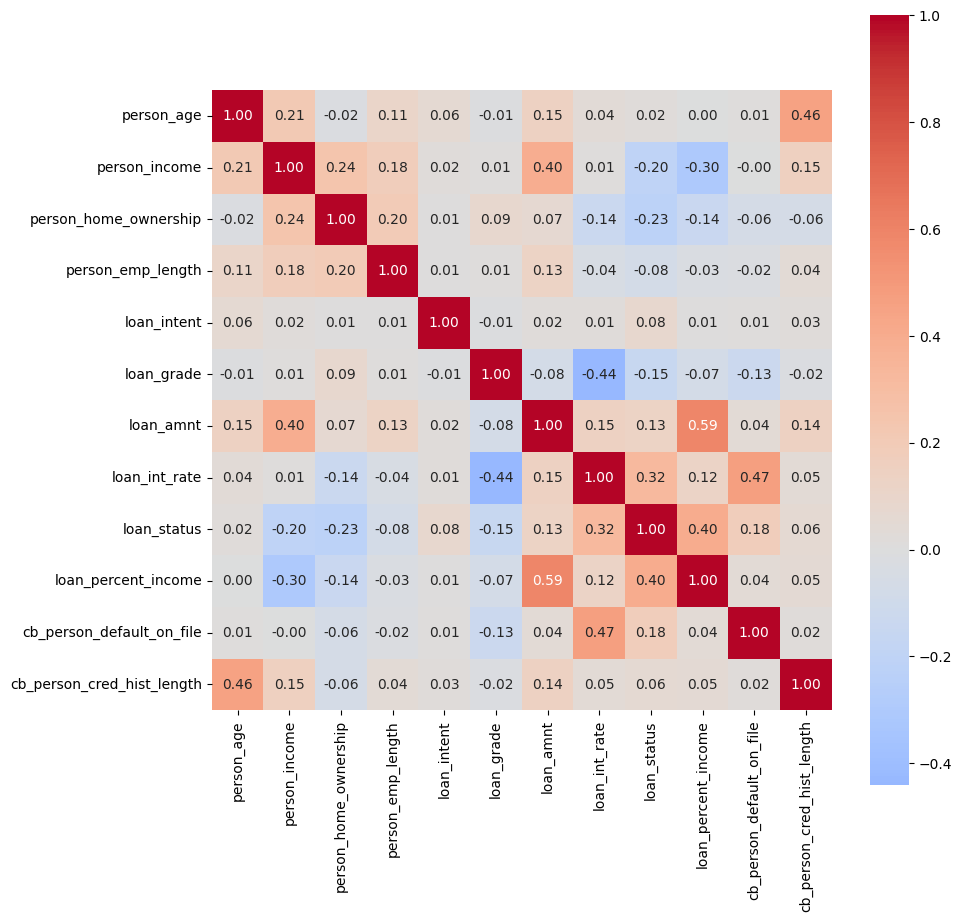

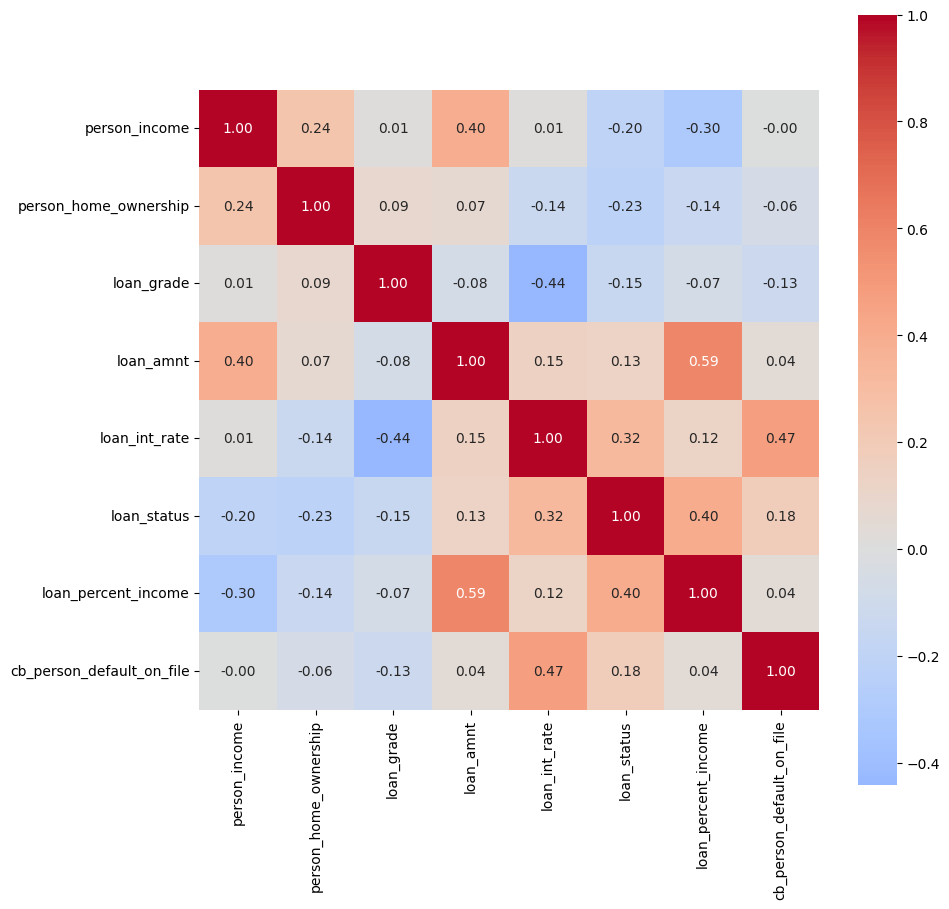

In [7]:
#Строю тепловую карту кореляции(потому что могу)
plt.figure(figsize=(10,10))
sns.heatmap(credit_df_clean.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
#На основе карты удаляю ненужные столбцы
credit_df_clean = credit_df_clean.drop(['person_age', 'person_emp_length', 'loan_intent', 'cb_person_cred_hist_length'], axis=1)
credit_df_clean
#Снова строю карту
plt.figure(figsize=(10,10))
sns.heatmap(credit_df_clean.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)

In [8]:
credit_df_clean

,person_income,person_home_ownership,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file
0,59000,1,1.0,35000.0,16.020000,1.0,0.59,1.0
1,9600,2,2.0,1000.0,11.140000,0.0,0.10,0.0
2,9600,3,3.0,5500.0,12.870000,1.0,0.57,0.0
3,65500,1,3.0,35000.0,15.230000,1.0,0.53,0.0
4,54400,1,3.0,35000.0,14.270000,1.0,0.55,1.0
...,...,...,...,...,...,...,...,...
19078,33600,1,3.0,14000.0,11.018222,1.0,0.42,1.0
19079,35000,1,3.0,14000.0,14.270000,1.0,0.40,1.0
19080,29000,1,2.0,14000.0,11.990000,1.0,0.48,0.0
19081,36000,1,4.0,14000.0,7.510000,1.0,0.39,0.0


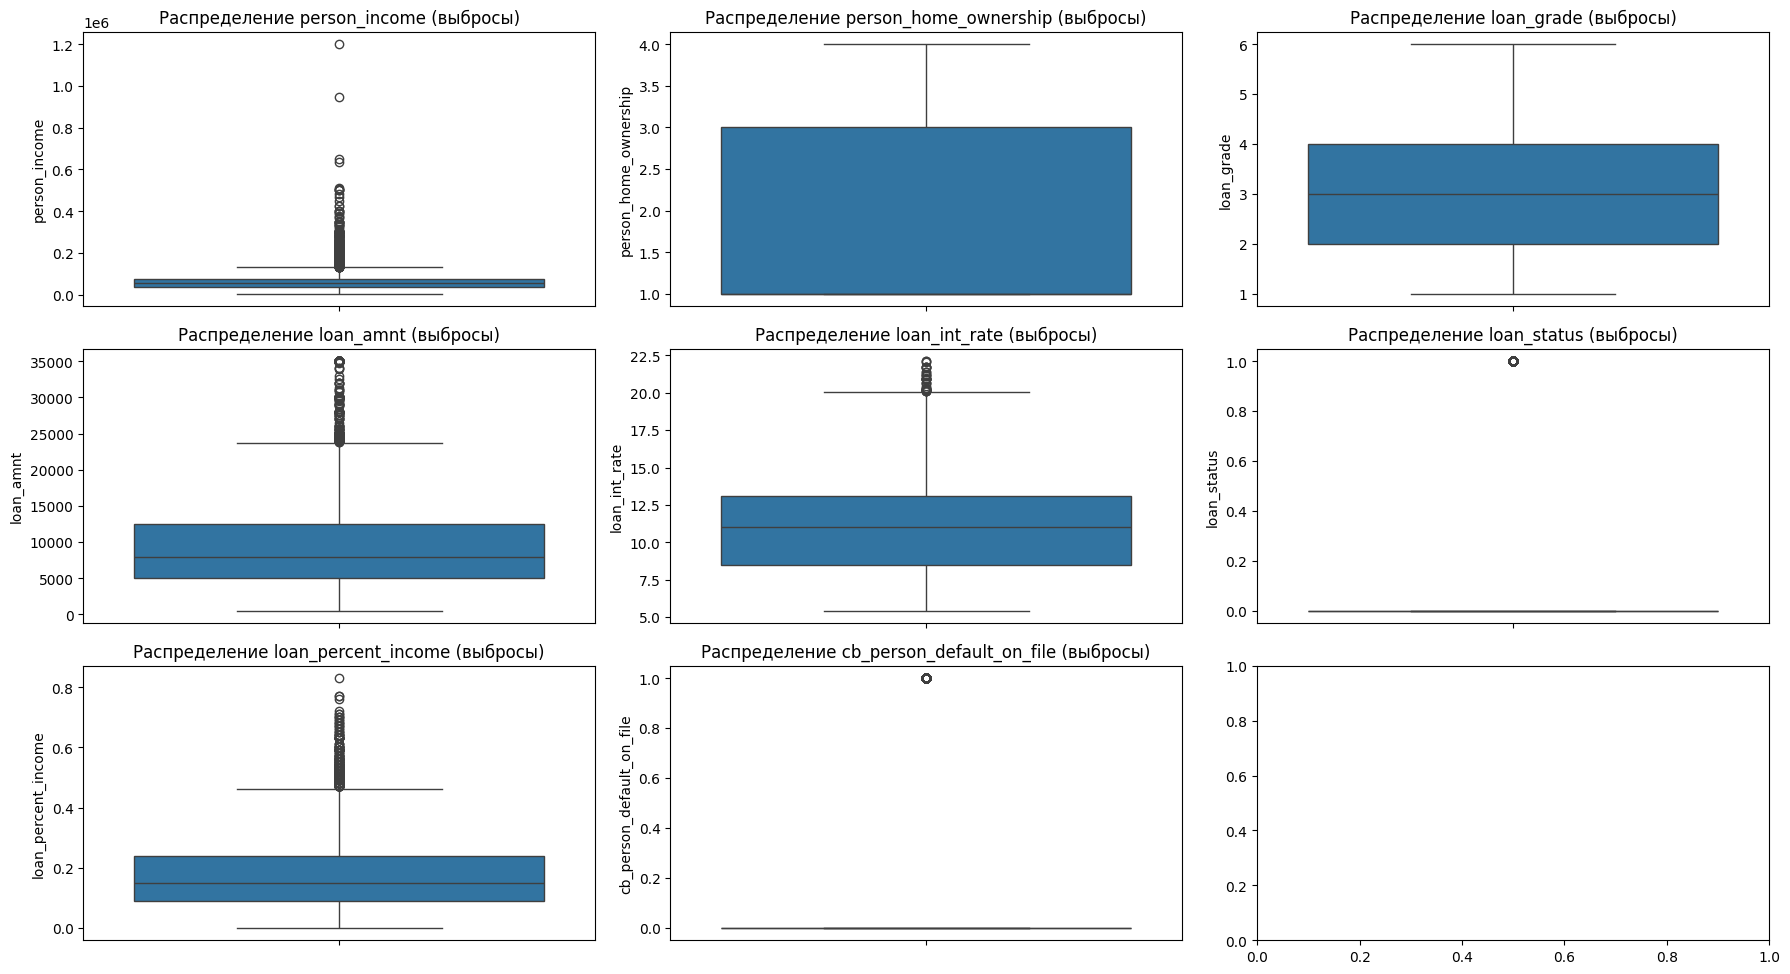

In [9]:
#Смотрю выбросы
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()
colums = credit_df_clean.columns.tolist()

for i, col in enumerate(colums):
    sns.boxplot(data=credit_df_clean, y=col, ax=axes[i])
    axes[i].set_title(f'Распределение {col} (выбросы)')

plt.tight_layout()
plt.show()

In [10]:
#Удаляю выбросы
def remove_outliers_iqr(df, column, multiplier=1.5, verbose=True):
    """Удаляет строки, где column выходит за пределы [Q1 - 1.5*IQR, Q3 + 1.5*IQR]"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    initial_len = len(df)
    df_filtered = df[(df[column] >= lower) & (df[column] <= upper)]
    removed = initial_len - len(df_filtered)
    if verbose:
        print(f"  {column}: удалено {removed} строк ({removed/initial_len*100:.1f}%)")
    return df_filtered

for col in credit_df_clean:
  if col == 'loan_status':
    next
  else:
    credit_df_clean = remove_outliers_iqr(credit_df_clean, col)

  person_income: удалено 896 строк (4.7%)
  person_home_ownership: удалено 0 строк (0.0%)
  loan_grade: удалено 1 строк (0.0%)
  loan_amnt: удалено 832 строк (4.6%)
  loan_int_rate: удалено 20 строк (0.1%)
  loan_percent_income: удалено 321 строк (1.9%)
  cb_person_default_on_file: удалено 2931 строк (17.2%)


In [11]:
#Создаю новые признаки
credit_df_clean

,person_income,person_home_ownership,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file
1,9600,2,2.0,1000.0,11.14,0.0,0.10,0.0
5,9900,2,4.0,2500.0,7.14,1.0,0.25,0.0
9,10000,2,1.0,1600.0,14.74,1.0,0.16,0.0
19,10800,3,2.0,1750.0,10.99,1.0,0.16,0.0
23,10980,2,4.0,1500.0,7.29,0.0,0.14,0.0
...,...,...,...,...,...,...,...,...
19072,35000,1,3.0,2125.0,15.27,0.0,0.06,0.0
19073,20000,1,2.0,2150.0,10.37,0.0,0.11,0.0
19074,24000,1,3.0,2150.0,14.72,0.0,0.09,0.0
19077,33200,1,4.0,14000.0,7.29,1.0,0.42,0.0


,person_income,person_home_ownership,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,loan_amnt_x_int_rate,prs_income_to_sqr_loan_amnt,loan_prs_income^prs_home_ownr,ln_amnt_x_int_rate,ln_prs_income^prs_home_ownr,ln_amnt*int_rate,ln_prs_income**prs_home_ownr
1,9600,2,2.0,1000.0,11.14,0.0,0.10,0.0,11140.0,0.009600,92160000,11140.0,92160000,11140.0,92160000
5,9900,2,4.0,2500.0,7.14,1.0,0.25,0.0,17850.0,0.001584,98010000,17850.0,98010000,17850.0,98010000
9,10000,2,1.0,1600.0,14.74,1.0,0.16,0.0,23584.0,0.003906,100000000,23584.0,100000000,23584.0,100000000
19,10800,3,2.0,1750.0,10.99,1.0,0.16,0.0,19232.5,0.003527,1259712000000,19232.5,1259712000000,19232.5,1259712000000
23,10980,2,4.0,1500.0,7.29,0.0,0.14,0.0,10935.0,0.004880,120560400,10935.0,120560400,10935.0,120560400



Корреляция новых признаков с loan_status:
ln_amnt*int_rate: 0.193
prs_income_to_sqr_loan_amnt: -0.071
ln_prs_income**prs_home_ownr: 0.009


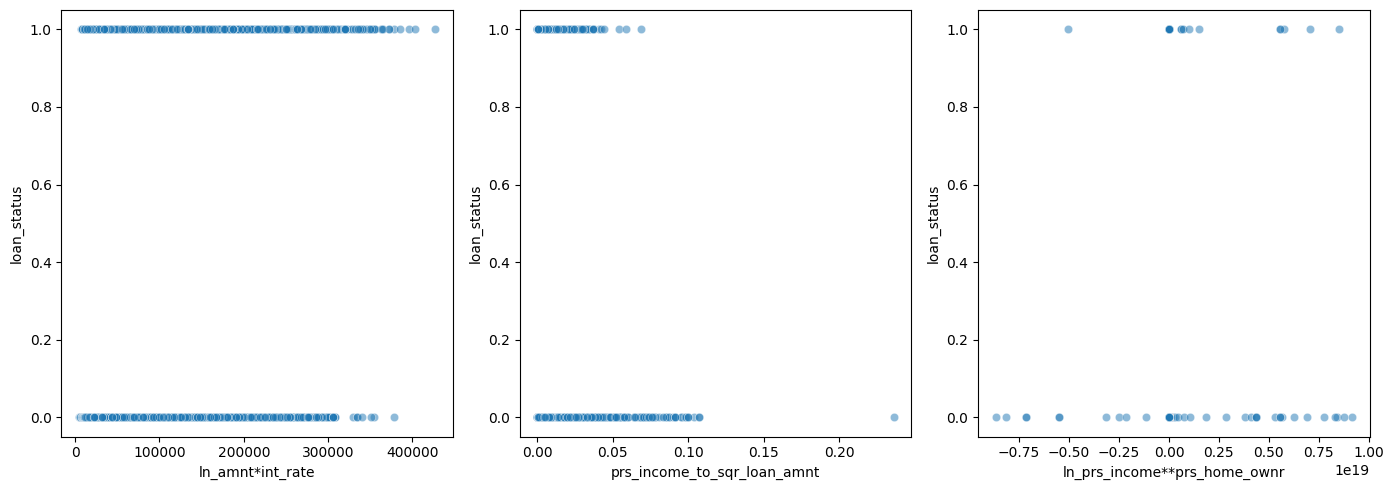

In [23]:
# ‼️‼️Добавление новых фич‼️‼️

# 1) Произведение суммы займа на процентную ставку
credit_df_clean['ln_amnt*int_rate'] = credit_df_clean['loan_amnt'] * credit_df_clean['loan_int_rate']

# 2) Доход делённый на квадрат суммы займа
credit_df_clean['prs_income_to_sqr_loan_amnt'] = credit_df_clean['person_income'] / ((credit_df_clean['loan_amnt']) ** 2 + 1e-6) # Прибавляем 1e-6, чтобы не было деления на 0

# 3) Процент дохода по займу в степени статуса владения домом
credit_df_clean['ln_prs_income**prs_home_ownr'] = credit_df_clean['person_income'] ** credit_df_clean['person_home_ownership']

# ln - loan; prs - person; ownr - ownership

display(credit_df_clean.head())

# Проверяем корреляцию с target
new_feats = ['ln_amnt*int_rate',
             'prs_income_to_sqr_loan_amnt',
             'ln_prs_income**prs_home_ownr'
             ]
print("\nКорреляция новых признаков с loan_status:")
for f in new_feats:
    corr = credit_df_clean[f].corr(credit_df_clean['loan_status'])
    print(f"{f}: {corr:.3f}")

# Визуализируем самые сильные зависимости
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
sns.scatterplot(data=credit_df_clean, x='ln_amnt*int_rate', y='loan_status', ax=axes[0], alpha=0.5)
#axes[0].set_title('Зависимость цены от объёма')
sns.scatterplot(data=credit_df_clean, x='prs_income_to_sqr_loan_amnt', y='loan_status', ax=axes[1], alpha=0.5)
#axes[1].set_title('Зависимость цены от квадрата карата')
sns.scatterplot(data=credit_df_clean, x='ln_prs_income**prs_home_ownr', y='loan_status', ax=axes[2], alpha=0.5)
#axes[2].set_title('Зависимость цены от квадрата карата')
plt.tight_layout()
plt.show()

In [24]:
#Разбираюсь с данными
colums.remove('loan_status')
X_data = credit_df_clean[colums]
y_target = credit_df_clean['loan_status']

ValueError: list.remove(x): x not in list

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_target, test_size=0.2, random_state=random.randint(1, 10000)
)

In [15]:
model = GradientBoostingClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Точность модели: {accuracy*100:.2f}%")

✅ Точность модели: 92.19%
